# Analyzing Method-specific Parameters using VISTA

Almost every ranking method has tunable parameters — thresholds, coefficients, preference functions — that shape its behavior. This notebook demonstrates how to use vistas to visually explore the effects of parameter changes. By sweeping a single parameter while holding everything else fixed, we can see exactly which regions of the criterion space are affected and how.

In [2]:
%matplotlib inline

from mcda_vista import generate_vista, plot_vista, plot_vista_grid, plot_vista_comparison, VistaResult
from mcda_vista.methods import get_method

## Indifference Threshold δ in TOPSIS

TOPSIS computes a closeness coefficient for each alternative. The additional δ (delta) parameter in our implementation defines how close two coefficients must be for the method to declare them indifferent. When δ = 0, there is no indifference zone — every pair is ordered. As δ grows, the yellow (indifferent) region expands around the boundary between *better* and *worse*.

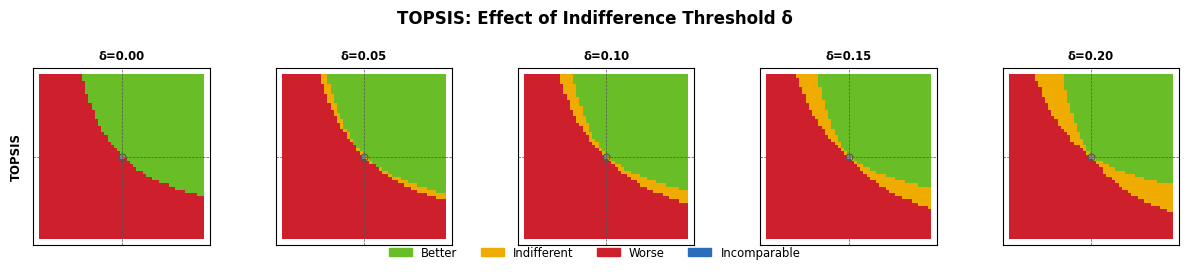

In [14]:
delta_values = [0.00, 0.05, 0.10, 0.15, 0.20]

topsis_results = [
    generate_vista("topsis", resolution=51, delta=d, progress=False)
    for d in delta_values
]

fig = plot_vista_grid(
    [topsis_results],
    row_labels=["TOPSIS"],
    col_labels=[f"δ={d:.2f}" for d in delta_values],
    title="TOPSIS: Effect of Indifference Threshold δ",
    point_size=5,
)

## Thresholds in ELECTRE III

ELECTRE III uses three thresholds per criterion:

- **q** — *indifference* threshold: differences below *q* are ignored,
- **p** — *preference* threshold: differences above *p* yield full preference,
- **v** — *veto* threshold: differences above *v* block outranking entirely.

Below we fix the veto threshold (v = 1.0), cut-level slope (α = −0.15) and intercept (β = 0.30), and sweep **q** and **p** over a 3 × 3 grid.

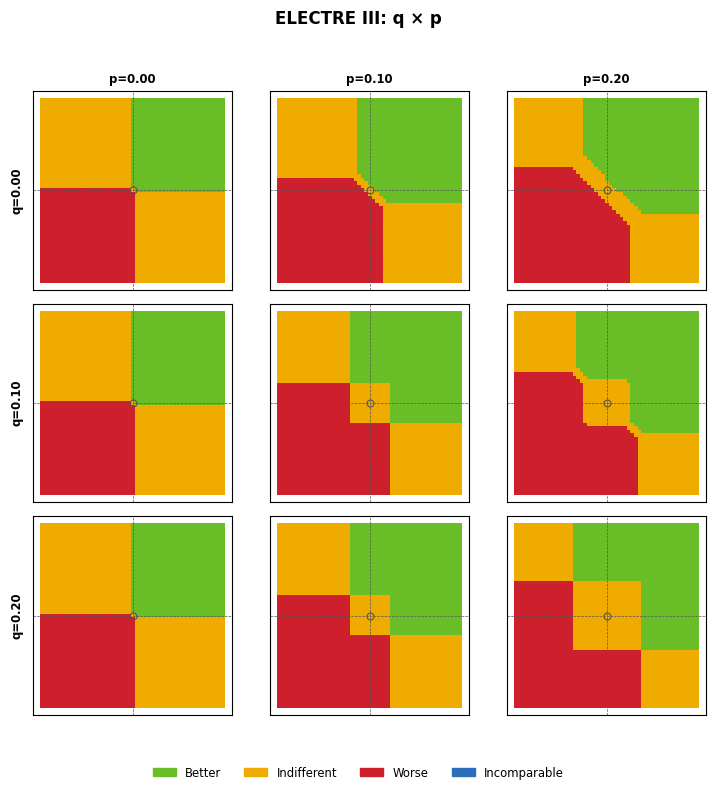

In [16]:
q_values = [0.00, 0.10, 0.20]
p_values = [0.00, 0.10, 0.20]

electre_base = dict(v=1.0, alpha=-0.15, beta=0.30)

electre_grid = [
    [
        generate_vista(
            "electre_iii", resolution=51,
            q=q, p=p, **electre_base,
            progress=False
        )
        for p in p_values
    ]
    for q in q_values
]

fig = plot_vista_grid(
    electre_grid,
    row_labels=[f"q={q:.2f}" for q in q_values],
    col_labels=[f"p={p:.2f}" for p in p_values],
    title="ELECTRE III: q × p",
    point_size=7
)

## Preference Functions in PROMETHEE I

PROMETHEE allows the user to choose a **preference function** that maps criterion-level differences to a degree of preference ∈ [0, 1]. The library supports seven types:

| Type | Name | Key feature |
|------|------|-------------|
| t1 | Usual | 0/1 step — any positive difference gives full preference |
| t2 | U-shape | q-threshold step — differences below *q* are ignored |
| t3 | V-shape | Linear increase from 0 to *p* |
| t4 | Level | Two-step: *q* → 0.5, *p* → 1.0 |
| t5 | V-shape with indifference | Linear between *q* and *p* |
| t6 | Gaussian | Smooth Gaussian curve controlled by *s* |

Below we generate a VISTA map for each type (t1 through t6), fixing q = 0.10, p = 0.20, s = 0.15.

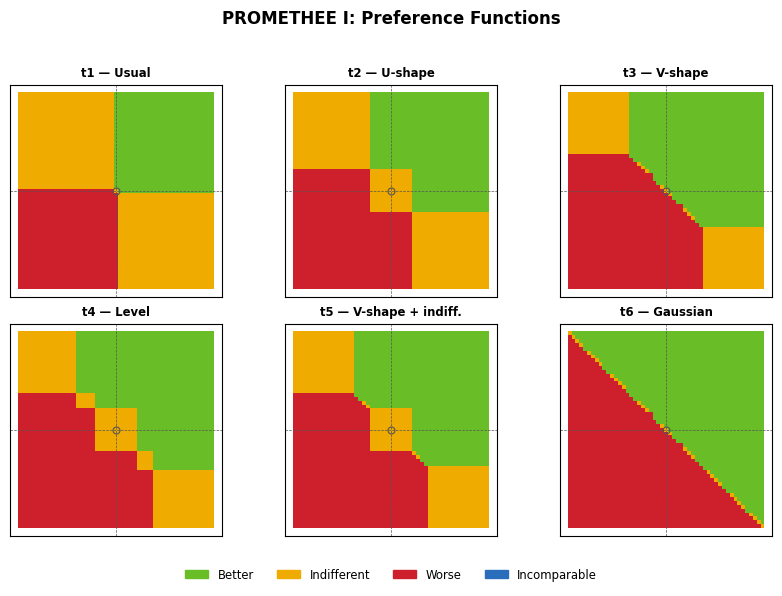

In [17]:
f_types = ["t1", "t2", "t3", "t4", "t5", "t6"]
f_labels = ["Usual", "U-shape", "V-shape", "Level", "V-shape + indiff.", "Gaussian"]

promethee_results = []
for ft, label in zip(f_types, f_labels):
    r = generate_vista(
        "promethee_i", resolution=51,
        f=ft, q=0.10, p=0.20, s=0.15,
        progress=False
    )
    # Override method_name for clearer subplot titles
    r = VistaResult(
        grid=r.grid, relations=r.relations, reference=r.reference,
        weights=r.weights, method_name=f"{ft} — {label}",
        params=r.params, resolution=r.resolution, n_criteria=r.n_criteria,
        third_alternative=r.third_alternative,
        extra_alternatives=r.extra_alternatives,
        metadata=r.metadata,
    )
    promethee_results.append(r)

fig = plot_vista_comparison(promethee_results, ncols=3, title="PROMETHEE I: Preference Functions", point_size=7)

## Reading Parameter Metadata

Every method adapter exposes a `param_space()` method that describes the name, range, default, and step size for each tunable parameter. This metadata drives the parameter sweeps above and also powers the interactive dashboard sliders.

In [18]:
for name in ["topsis", "vikor", "electre_iii", "promethee_i"]:
    adapter = get_method(name)
    print(f"\n{adapter.display_name}")
    print("-" * 40)
    for pname, meta in adapter.param_space().items():
        if "choices" in meta:
            print(f"  {pname:10s}  choices={meta['choices']}  "
                  f"default={meta['default']}  "
                  f"label={meta['label']!r}")
        else:
            print(f"  {pname:10s}  range=[{meta['min']}, {meta['max']}]  "
                  f"default={meta['default']}  step={meta['step']}  "
                  f"label={meta['label']!r}")


TOPSIS
----------------------------------------
  delta       range=[0.0, 0.5]  default=0.1  step=0.05  label='δ (indifference threshold)'

VIKOR
----------------------------------------
  v           range=[0.0, 1.0]  default=0.5  step=0.25  label='v (strategy coefficient)'

ELECTRE III
----------------------------------------
  q           range=[0.0, 0.5]  default=0.1  step=0.05  label='q (indifference)'
  p           range=[0.0, 1.0]  default=0.2  step=0.05  label='p (preference)'
  v           range=[0.1, 2.0]  default=1.0  step=0.1  label='v (veto)'
  alpha       range=[-0.5, 0.0]  default=-0.15  step=0.05  label='α (cut-level slope)'
  beta        range=[0.0, 1.0]  default=0.3  step=0.05  label='β (cut-level intercept)'

PROMETHEE I
----------------------------------------
  f           choices=['t1', 't2', 't3', 't4', 't5', 't6', 't7']  default=t4  label='Preference function type'
  q           range=[0.0, 0.5]  default=0.1  step=0.05  label='q (indifference)'
  p           ra

The `VistaResult` object also stores the exact parameters used in a run, along with timing information:

In [19]:
# Pick one of the TOPSIS results from the earlier sweep
sample = topsis_results[2]  # delta=0.10

print("Method:          ", sample.method_name)
print("Parameters:      ", sample.params)
print("Elapsed seconds: ", sample.metadata.get("elapsed_seconds", "N/A"))

Method:           topsis
Parameters:       {'delta': 0.1}
Elapsed seconds:  0.13515499999630265
